In [4]:
import os #os for file path operations
import pandas as pd # pandas for data manipulation
import numpy as np # numpy for numerical operations
import seaborn as sns # seaborn for data visualization
import re #regex for text processing

import nltk #nltk for natural language processing
from nltk.corpus import stopwords #stopwords for text processing
from nltk.tokenize import word_tokenize #word_tokenize for text processing
from nltk.stem import WordNetLemmatizer # WordNetLemmatizer for text processing

from sklearn.model_selection import train_test_split #train_test_split for splitting data
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier #classifiers
from sklearn.linear_model import LogisticRegression, PassiveAggressiveClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder


In [14]:
df = pd.read_csv("D:/UCB/Projectdocuments/Resume Project/Resume.zip", compression='zip')

#df = pd.read_csv('https://github.com/maniliy07/ML/blob/main/Resume.zip', compression='zip')


In [ ]:
df.head() #display first few rows
df.info() #check for null values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2484 entries, 0 to 2483
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   ID           2484 non-null   int64 
 1   Resume_str   2484 non-null   object
 2   Resume_html  2484 non-null   object
 3   Category     2484 non-null   object
dtypes: int64(1), object(3)
memory usage: 77.8+ KB


In [ ]:
df=df.drop(['ID','Resume_html'],axis=1) #drop unnecessary columns

In [36]:
df.head()

,Resume_str,Category
0,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,HR
1,"HR SPECIALIST, US HR OPERATIONS ...",HR
2,HR DIRECTOR Summary Over 2...,HR
3,HR SPECIALIST Summary Dedica...,HR
4,HR MANAGER Skill Highlights ...,HR


<Axes: title={'center': 'Category Distribution'}, xlabel='Category'>

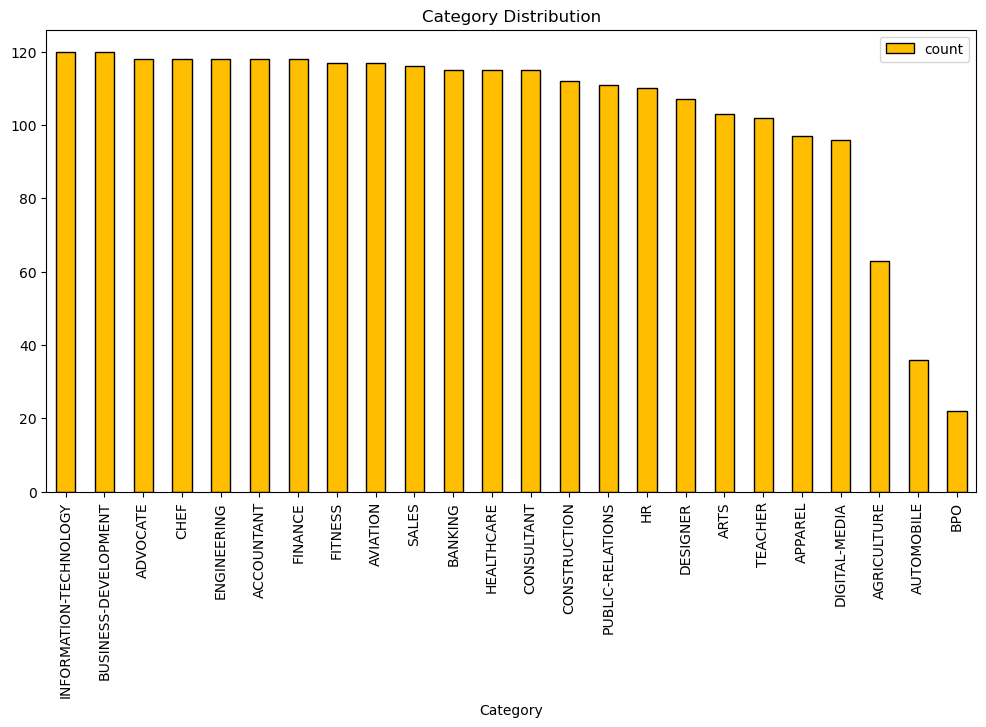

In [ ]:
df["Category"].value_counts().plot(kind="bar", figsize=(12,6), title="Category Distribution",legend='True',color='#FFBF00',edgecolor='black') #visualize category distribution

In [ ]:
nltk.download('punkt', quiet=True) #download punkt tokenizer
nltk.download('stopwords', quiet=True) #download stopwords
nltk.download('wordnet', quiet=True) #download wordnet for lemmatization

stop_words = set(stopwords.words('english')) #set of english stopwords
lemmatizer = WordNetLemmatizer() #initialize lemmatizer

In [42]:
def clean(text):
    if pd.isna(text): return ""
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+|https\S+','',text,flags=re.MULTILINE) 
    text = re.sub(r'\s+',' ',text).strip() 

    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(token) for token in tokens if token not in stop_words and len(token)>2]

    return ' '.join(tokens)

df["cleaned"] = df["Resume_str"].apply(clean)
df.head()

,Resume_str,Category,cleaned
0,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,HR,administrator/marketing associate administrato...
1,"HR SPECIALIST, US HR OPERATIONS ...",HR,specialist operation summary versatile medium ...
2,HR DIRECTOR Summary Over 2...,HR,director summary year experience recruiting pl...
3,HR SPECIALIST Summary Dedica...,HR,specialist summary dedicated driven dynamic ye...
4,HR MANAGER Skill Highlights ...,HR,manager skill highlight skill department start...


In [ ]:
x = df["cleaned"] #features
y = df["Category"] #target variable column Category

le = LabelEncoder() #initialize label encoder
yn = le.fit_transform(y) #encode target variable

In [ ]:
X_train,X_test,Y_train,Y_test = train_test_split(x,yn,test_size=0.2,stratify=y,random_state=42)  #split data into training and testing sets with stratification

In [ ]:
count_vectorizer = CountVectorizer(max_features=5000) #initialize CountVectorizer
tfidf_vectorizer = TfidfVectorizer(max_features=5000) #initialize TfidfVectorizer

x_trainc = count_vectorizer.fit_transform(X_train) #fit and transform training data
x_testc = count_vectorizer.transform(X_test) #transform testing data

x_traint = tfidf_vectorizer.fit_transform(X_train) #fit and transform training data
x_testt = tfidf_vectorizer.transform(X_test) #transform testing data

In [ ]:
models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'SVM': SVC(random_state=42),
    'Naive Bayes': MultinomialNB(),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'Passive Aggressive': PassiveAggressiveClassifier(max_iter=1000, random_state=42)
} #initialize models

In [ ]:
best_acc = 0 #variable to store best accuracy
best_name = None #variable to store best model name
best_preds = None #variable to store best model predictions

for name, model in models.items():
    model.fit(x_trainc, Y_train)
    preds = model.predict(x_testc)
    acc = accuracy_score(Y_test, preds)
    if acc > best_acc:
        best_acc = acc
        best_name = name
        best_preds = preds

print(f"\nBest Model: {best_name} with accuracy {best_acc:.4f}")  
print(classification_report(Y_test, best_preds, target_names=le.classes_))

c:\Users\test\anaconda3\Lib\site-packages\xgboost\training.py:199: UserWarning: [17:38:27] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Best Model: Gradient Boosting with accuracy 0.7364
                        precision    recall  f1-score   support

            ACCOUNTANT       0.85      0.92      0.88        24
              ADVOCATE       0.91      0.88      0.89        24
           AGRICULTURE       0.75      0.46      0.57        13
               APPAREL       0.55      0.32      0.40        19
                  ARTS       0.55      0.57      0.56        21
            AUTOMOBILE       0.50      0.29      0.36         7
              AVIATION       0.81      0.71      0.76        24
               BANKING       0.83      0.65      0.73        23
                   BPO       0.67      0.50      0.57         4
  BUSINESS-DEVELOPMENT       0.52      0.67      0.58        24
                  CHEF       0.91      0.83      0.87        24
          CONSTRUCTION       0.95      0.91      0.93        22
            CONSULTANT       0.54      0.65      0.59        23
              DESIGNER       0.81      1.00      0.